In [1]:
pip install polars

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\Asus\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
pip install seaborn pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\Asus\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# EDA

In [3]:
import os
base_path = os.getcwd()
print(base_path)

c:\Users\Asus\Documents\Perancangan-Bid-Data


In [4]:
import polars as pl

local_parquet_path = os.path.join(base_path, "data", "train.parquet")

# Menggunakan scan_parquet (Lazy) agar RAM tetap hemat
# Data hanya diproses saat .collect() dipanggil
df_pq = pl.scan_parquet(local_parquet_path)

In [5]:
df_sample = df_pq.head(15_000_000).collect()

print(f"Data berhasil disimpan di variabel 'df_sample'. Jumlah baris: {len(df_sample)}")
display(df_sample)

Data berhasil disimpan di variabel 'df_sample'. Jumlah baris: 15000000


ip,app,device,os,channel,click_time,attributed_time,is_attributed
i64,i64,i64,i64,i64,str,str,i64
83230,3,1,13,379,"""2017-11-06 14:32:21""",null,0
17357,3,1,19,379,"""2017-11-06 14:33:34""",null,0
35810,3,1,13,379,"""2017-11-06 14:34:12""",null,0
45745,14,1,13,478,"""2017-11-06 14:34:52""",null,0
161007,3,1,13,379,"""2017-11-06 14:35:08""",null,0
…,…,…,…,…,…,…,…
85065,12,2,40,265,"""2017-11-07 01:37:13""",null,0
113719,3,1,31,424,"""2017-11-07 01:37:13""",null,0
43547,3,1,13,480,"""2017-11-07 01:37:13""",null,0


In [6]:
from feature_engineering import generate_fraud_features

In [7]:
df_new=generate_fraud_features(df_sample)

In [8]:
df_new

ip,app,device,os,channel,click_time,attributed_time,is_attributed,click_hour,click_minute,seconds_since_prev_click,ip_clicks_last_10m,fingerprint_clicks_last_1h,ip_unique_channels_per_hour
i64,i64,i64,i64,i64,datetime[μs],str,i64,i8,i8,i64,u32,u32,u32
83230,3,1,13,379,2017-11-06 14:32:21,null,0,14,32,-1,1,1,1
17357,3,1,19,379,2017-11-06 14:33:34,null,0,14,33,-1,1,1,1
35810,3,1,13,379,2017-11-06 14:34:12,null,0,14,34,-1,1,1,1
45745,14,1,13,478,2017-11-06 14:34:52,null,0,14,34,-1,1,1,1
161007,3,1,13,379,2017-11-06 14:35:08,null,0,14,35,-1,1,1,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…
85065,12,2,40,265,2017-11-07 01:37:13,null,0,1,37,8766,13,1,49
113719,3,1,31,424,2017-11-07 01:37:13,null,0,1,37,9,34,5,52
43547,3,1,13,480,2017-11-07 01:37:13,null,0,1,37,1381,11,4,19


In [9]:
# Menghitung statistik deskriptif: mean, std, min, q1, median, q3, max
display(df_new.describe())

statistic,ip,app,device,os,channel,click_time,attributed_time,is_attributed,click_hour,click_minute,seconds_since_prev_click,ip_clicks_last_10m,fingerprint_clicks_last_1h,ip_unique_channels_per_hour
str,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64
"""count""",1.5e7,1.5e7,1.5e7,1.5e7,1.5e7,"""15000000""","""32060""",1.5e7,1.5e7,1.5e7,1.5e7,1.5e7,1.5e7,1.5e7
"""null_count""",0.0,0.0,0.0,0.0,0.0,"""0""","""14967940""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",87149.582699,12.567688,32.438879,24.409011,255.762945,"""2017-11-06 21:47:53.099988""",null,0.002137,12.219843,27.825202,506.452399,83.069943,67.837706,39.972828
"""std""",55733.859004,16.297672,306.066491,60.995667,128.474159,null,null,0.046182,9.541527,17.080055,2598.525485,231.702562,216.251594,24.393246
"""min""",9.0,0.0,0.0,0.0,0.0,"""2017-11-06 14:32:21""","""2017-11-06 16:00:47""",0.0,0.0,0.0,-1.0,1.0,1.0,1.0
"""25%""",41822.0,3.0,1.0,13.0,135.0,"""2017-11-06 18:11:57""",null,0.0,1.0,13.0,0.0,13.0,9.0,20.0
"""50%""",81792.0,12.0,1.0,18.0,245.0,"""2017-11-06 23:16:56""",null,0.0,16.0,27.0,3.0,25.0,21.0,37.0
"""75%""",121278.0,15.0,1.0,19.0,371.0,"""2017-11-07 00:32:25""",null,0.0,21.0,42.0,37.0,54.0,48.0,57.0
"""max""",212774.0,675.0,3545.0,745.0,498.0,"""2017-11-07 01:37:13""","""2017-11-07 15:59:53""",1.0,23.0,59.0,35970.0,3299.0,4161.0,117.0


In [10]:
import polars as pl

# Menghitung baris dengan clicks > 5 dan > 10
count_gt_5 = df_new.filter(pl.col("ip_clicks_last_10m") > 5).height
count_gt_10 = df_new.filter(pl.col("ip_clicks_last_10m") > 10).height

print(f"Jumlah baris dengan ip_clicks_last_10m > 5: {count_gt_5:,}")
print(f"Jumlah baris dengan ip_clicks_last_10m > 10: {count_gt_10:,}")

# Menampilkan persentase dari total data
total_rows = len(df_new)
print(f"\nPersentase (> 5): {(count_gt_5 / total_rows * 100):.2f}%")
print(f"Persentase (> 10): {(count_gt_10 / total_rows * 100):.2f}%")

Jumlah baris dengan ip_clicks_last_10m > 5: 13,531,515
Jumlah baris dengan ip_clicks_last_10m > 10: 11,896,863

Persentase (> 5): 90.21%
Persentase (> 10): 79.31%


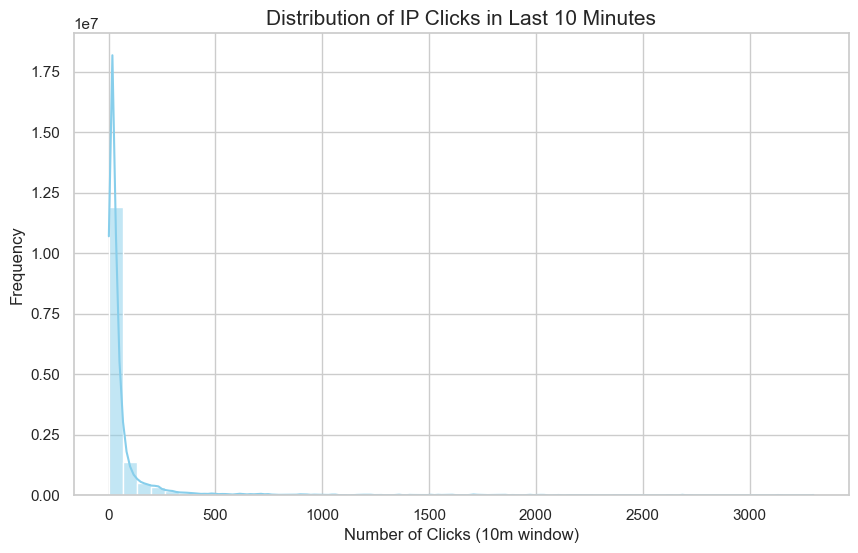

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plot histogram for ip_clicks_last_10m tanpa log scale
sns.histplot(df_new["ip_clicks_last_10m"].to_pandas(), bins=50, kde=True, color='skyblue')

plt.title("Distribution of IP Clicks in Last 10 Minutes", fontsize=15)
plt.xlabel("Number of Clicks (10m window)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

### Distribution of `seconds_since_prev_click`

This feature represents the time difference between consecutive clicks from the same `(ip, device, os)` combination. Very small values (near 0) or values equal to -1 (for the first click) could indicate bot-like behavior or a user clicking very rapidly.

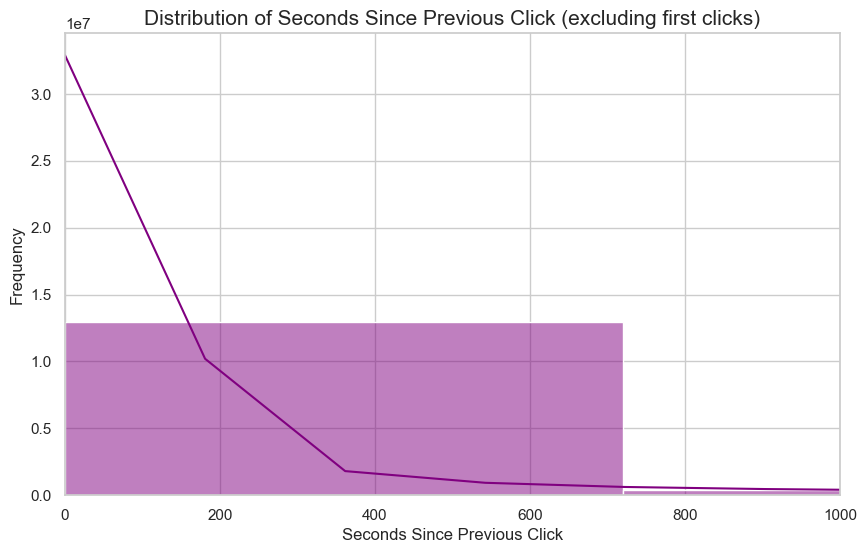

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df_new.filter(pl.col("seconds_since_prev_click") >= 0)['seconds_since_prev_click'].to_pandas(), bins=50, kde=True, color='purple')
plt.title("Distribution of Seconds Since Previous Click (excluding first clicks)", fontsize=15)
plt.xlabel("Seconds Since Previous Click", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xlim(0, 1000) # Focusing on the lower range for better visibility of rapid clicks
plt.show()

### Distribution of `ip_unique_channels_per_hour`

This feature measures the diversity of channels used by a specific IP address within a 1-hour window. A very high number of unique channels from a single IP might suggest bot activity or a compromised IP.

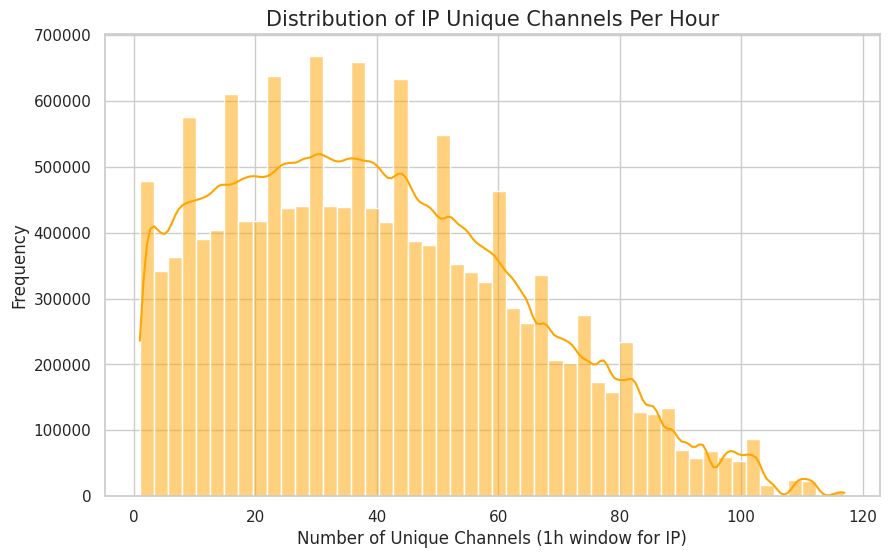

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_new['ip_unique_channels_per_hour'].to_pandas(), bins=50, kde=True, color='orange')
plt.title("Distribution of IP Unique Channels Per Hour", fontsize=15)
plt.xlabel("Number of Unique Channels (1h window for IP)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

In [17]:
df_new.columns

['ip',
 'app',
 'device',
 'os',
 'channel',
 'click_time',
 'attributed_time',
 'is_attributed',
 'click_hour',
 'click_minute',
 'seconds_since_prev_click',
 'ip_clicks_last_10m',
 'fingerprint_clicks_last_1h',
 'ip_unique_channels_per_hour']